## About this doc

`-` 우분투에서 여러가지 개발환경을 설정하는 방법을 포스팅 (시대가 너무 바뀌어서 새로정리)

## 우분투설치 

`-` Nomal installation $\to$ Erase disk and install Ubuntu, Continue

::: {.panel-tabset}
### step1 

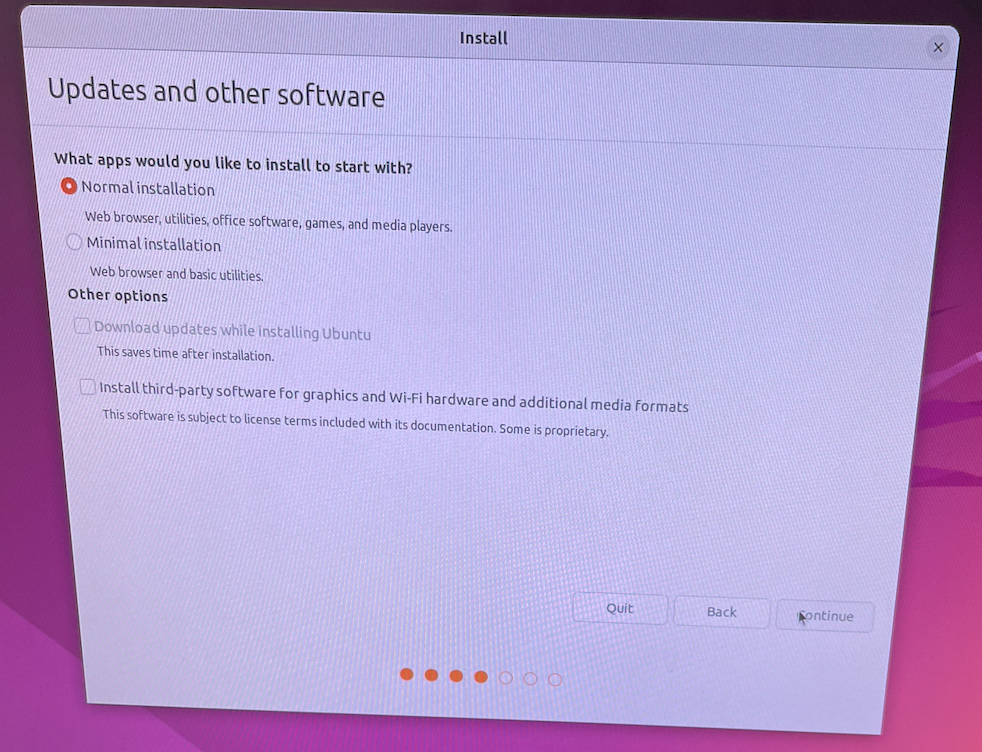

### step2

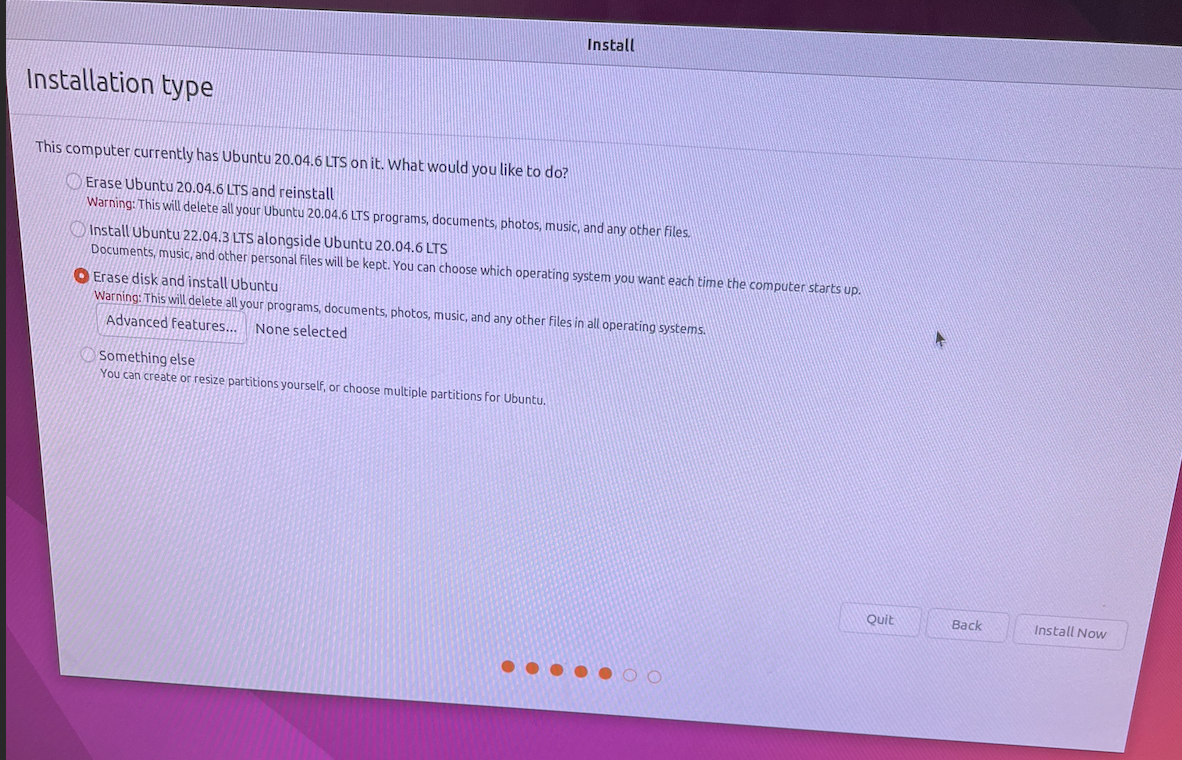

### step3

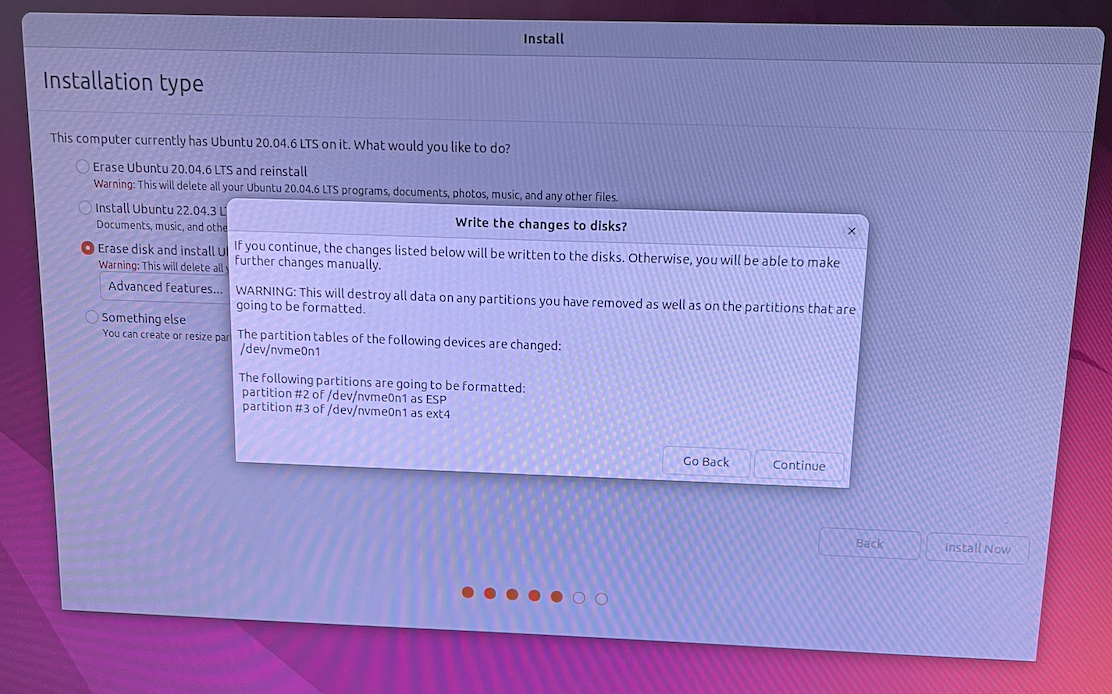
:::

## 네트워크 설정

`-` `?`표시있는 아이콘 $\to$ Wired Connected $\to$ Wired Settings $\to$ Connection의 설정 $\to$ IPv4 $\to$ Manual $\to$ Address, Netmask, Gateway, DNS 설정 $\to$ 네트워크 토글 


## 그래픽카드 드라이버설치

`-` 전체적인 내용은 [여기](https://gist.github.com/bendangnuksung/981408031699e0ddc50a6f6fdcf185c2)를 참고하자. 

`-` 준비작업 

```bash
sudo apt update 
sudo apt install gcc
sudo apt install build-essential
```

`-` 우선 `gedit`를 열고 아래를 복사해서 붙여넣는다. 

```bash
blacklist nouveau
options nouveau modeset=0
```

파일이름을 `blacklist-nouveau.conf`로 `home`에 저장

`-` 루트권한획득 

```bash
sudo -i
```
아이디와 비밀번호를 입력하고 루트권한을 얻는다. 

`-` 아래를 입력한다. 

```bash
sudo cp /home/cgb2/blacklist-nouveau.conf /etc/modprobe.d
sudo update-initramfs -u
sudo reboot 
```

`-` 그래픽카드 다운로드: 드라이버 설치파일을 다운받는다. [앤비디아공식홈페이지](https://www.geforce.com/drivers)에서 다운받자. OS를 리눅스 64-bit으로 선택하고 검색을 누르면 다운받아진다. 

`-` 그래픽키다 설치: 다운받은뒤에는 파일이 있는 폴더로 이동하여 

```bash
chmod +x NVIDIA-Linux-x86_64-410.78.run
```

를 실행하자. 보통 `NVI`까지치고 적당히 `탭`을 누르면 알아서 뒷부분이 완성된다. 이 과정은 추후에 
드라이버를 실행할수 있도록 권한을 풀어두는 것이다. 그리고 아래를 실행한다.

```bash
sudo ./NVIDIA-Linux-x86_64-410.78.run
```

그 다음 드라이버가 잘 설치되었는지 확인한다. 

```bash
nvidia-smi
```

## ssh연결 

`-` 처음에 ssh를 연결하기위해서는 연결**당하는** 컴퓨터에 가서 아래를 실행해야 한다. 

```bash
sudo apt install openssh-server
```

***22번포트 우회하기***

`-` step1: `/etc/ssh/sshd_config` 파일을 연다. 

```bash
sudo vi /etc/ssh/sshd_config 
```

`-` step2: Port 22 라고 된 부분의 주석을 풀고 원하는 포트번호 설정 

```bash
...

#Port 22
#AddressFamily any
#ListenAddress 0.0.0.0
#ListenAddress ::

...
```




`-` step3: 수정내용을 적용 

```bash
sudo systemctl restart ssh.service
```

`-` step4: 수정한 포트로 ssh접속 

## 아나콘다

`-` 다운로드: <https://www.anaconda.com/download>

`-` (아나콘다 설치) 아나콘다를 다운받은 폴더로 가서 아래와 같이 실행한다. 

```bash
bash Anaconda3-2019.03-Linux-x86_64.sh
```

대충 `bash Ana` 정도까지만 치고 `tab`을 누르면 알아서 완성된다. 


## 원격제어

### 주피터 원격제어 설정

`-` 설정파일 생성 

```bash
jupyter notebook --generate-config
```

`-` 패스워드 설정 

```bash
jupyter notebook password
## 패스워드 치고
## 확인해야함
```

`-` 설정파일을 열고

```bash
vi /home/cgb2/.jupyter/jupyter_notebook_config.py
```

아래의 내용을 수정한다.

```default
c.??????App.ip = '192.168.0.4'
c.??????App.port = 1306
c.??????App.allow_origin = '*'
c.??????App.allow_remote_access = True
c.??????App.allow_root = True
```

### vscode

`-` ref: https://code.visualstudio.com/docs/remote/tunnels

`-` 아래를 실행하면 된다. 

```bash
curl -Lk 'https://code.visualstudio.com/sha/download?build=stable&os=cli-alpine-x64' --output vscode_cli.tar.gz
tar -xf vscode_cli.tar.gz
```

`-` 이후로는 `./code tunnel`을 실행할것!

`-` 백엔드에서 하려면 

```bash
nohup ./code tunnel > /dev/null 2>&1 &
```

`-` 패키지설치

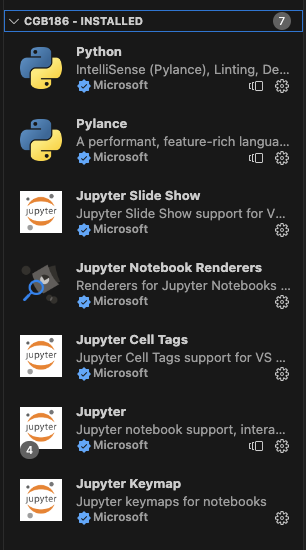

## Rstudio

`-` 가상환경만듦 

```bash
(base) conda create -n r 
(base) conda activate r 
(r) conda install -c conda-forge r-essentials
```

`-` 아래를 이용하여 [Rstudio](https://rstudio.com/products/rstudio/download-server/debian-ubuntu/)를 설치 (base환경인지 r환경인지는 무의미) 

```bash
sudo apt remove rstudio-server # 이미 설치된 경우 이 명령을 통하여 삭제하고 설치할 것 
sudo apt-get install gdebi-core
wget https://download2.rstudio.org/server/jammy/amd64/rstudio-server-2024.04.2-764-amd64.deb # 우분투 22는 jammy!!!
sudo gdebi rstudio-server-2024.04.2-764-amd64.deb
```

`-` `grst`가 만든 `rstudio-server-conda`를 클론 

```bash
git clone https://github.com/grst/rstudio-server-conda.git
```

`-` 내용을 수정

```{.bash filename=~/rstudio-server-conda/local/start_rstudio_server.sh}

아래쪽으로 쭉 가면...

/usr/lib/rstudio-server/bin/rserver --server-daemonize=0 \
  --www-port=????? \ ### <--- 여기 수정!!!!!
  --secure-cookie-key-file=$COOKIE_KEY_PATH \
  --server-pid-file="$CWD/rstudio-server.pid" \
  --server-data-dir="$CWD/rstudio-server" \
  --rsession-which-r=$(which R) \
  --rsession-ld-library-path=$CONDA_PREFIX/lib \
  --rsession-path="$CWD/rsession.sh" \
  --server-user $USER \
  --database-config-file "$CWD/database.conf" \
  $REVOCATION_LIST_PAR
```

`-` `start_rstudio_server.sh`를 실행 

## 유용한 콘다 개발환경 

### R+Python 사용가능한 개발환경 


`-` 아래를 실행

```bash
(base) conda create -n r 
(base) conda activate r
(r) conda install -c conda-forge r-essentials
(r) conda install -c conda-forge plotly
(r) conda install -c conda-forge rpy2
```

In [1]:
import rpy2

`-` 여기에서 `conda install -c conda-forge r-essentials`로 인하여 R, Python, Jupyter 가 모두 최신버전으로 설치된다. 

`-` 또한 R에는 이미 `tidyverse`, `IRkernel` 등의 패키지가 기본으로 깔려있다. 

`-` 커널연결 

콘다환경에서 R을 실행한다. Rstudio가 아니라 커맨드에서 R을 실행해야한다. 그리고 아래를 실행하면 주피터랩과 R환경이 연결된다. 

```R
IRkernel::installspec()
```

이제 주피터랩에서 R kernel을 사용할 수 있다. 

`-` R은 아래의 경로에 설치되어있다. 

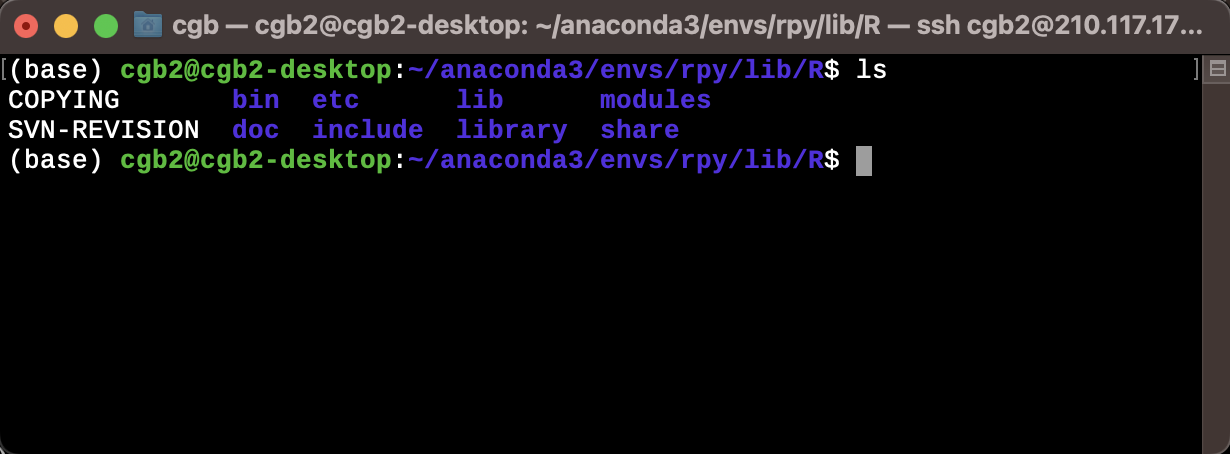

`-` 실행파일은 bin 폴더에 있다. 

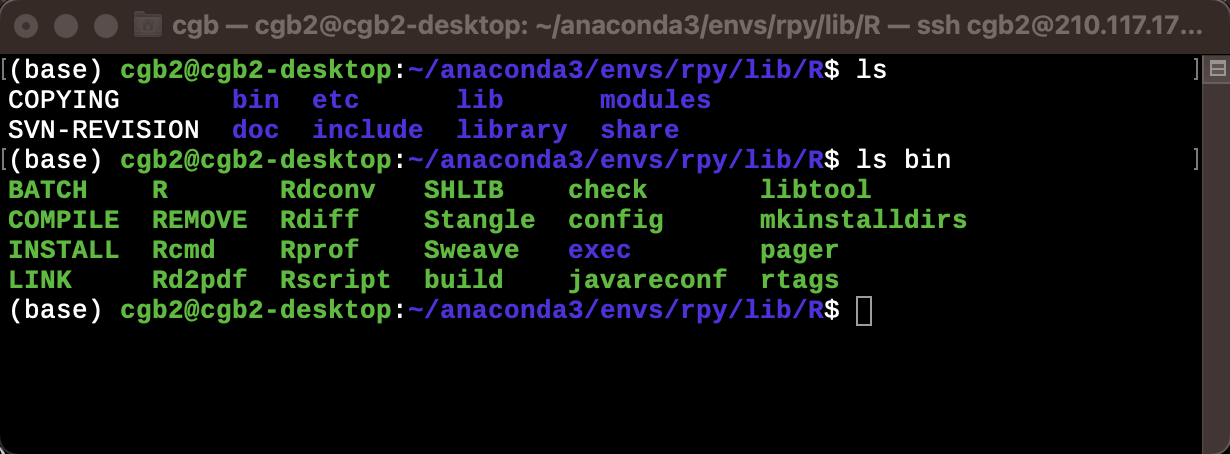

`(base)` 환경이지만 이곳의 실행파일에 직접 접근하여 실행할 수도 있다. 

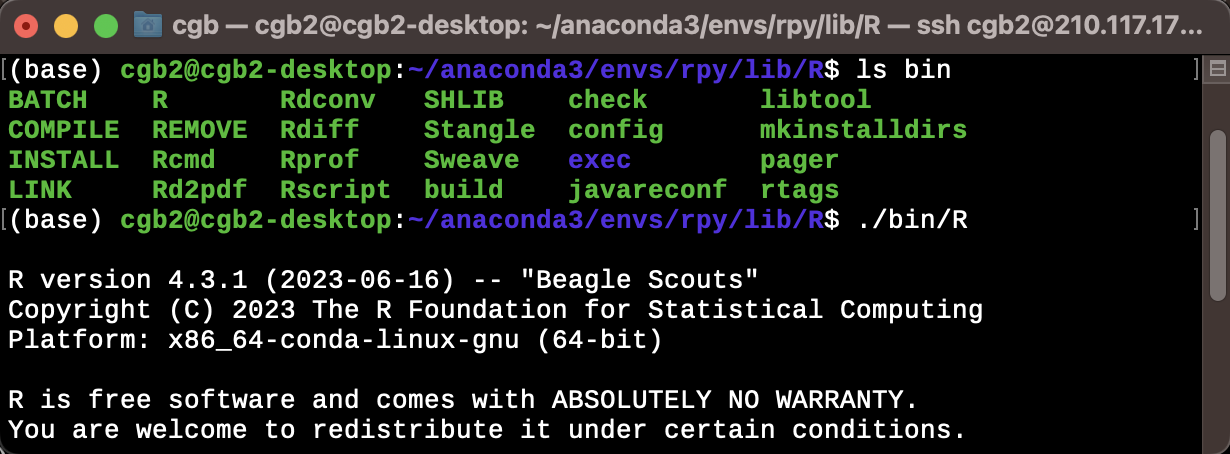

`-` 설치한 패키지는 library 폴더에 있다. /// `EPT`도 보인다..

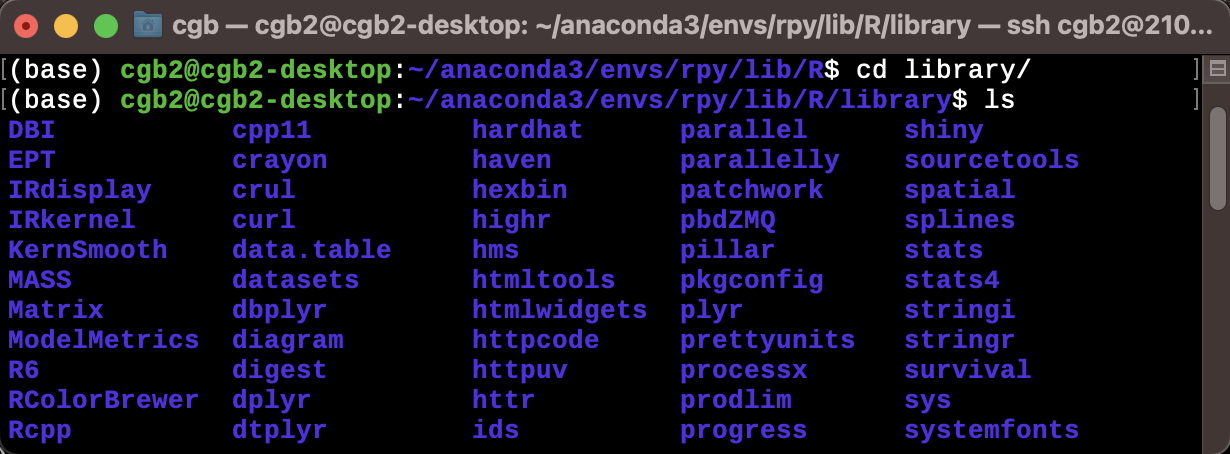

### torch


`-` 아래를 실행

```bash
(base) conda create -n torch
(base) conda activate torch
#---#
(torch) conda install -c conda-forge notebook 
(torch) conda install -c conda-forge plotly 
#---torch--#
(torch) conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
#---pyg---#
#(torch) conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
(torch) conda install pyg -c pyg 
#---stgcn---#
#(torch) conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
#(torch) conda install pyg -c pyg 
(torch) sudo apt install gcc
(torch) sudo apt install build-essential
(torch) pip install torch-geometric-temporal
#---ctgan---#
#(torch) conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
(torch) conda install -c pytorch -c conda-forge ctgan  
#---gym---#
#(torch) conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
(torch) pip install gymnasium 
#(torch) sudo apt install gcc
#(torch) sudo apt install build-essential
(torch) sudo apt-get install swig
(torch) pip install gymnasium[box2d]
```

**refs**

- PyTorch: <https://pytorch.org/get-started/locally/>
- PyG: <https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html>
- PyTorch Geometric Temporal^[이 패키지는 꼭 PyG 이후에 설치할것]: <https://pytorch-geometric-temporal.readthedocs.io/en/latest/notes/installation.html>
- CTGAN: <https://github.com/sdv-dev/CTGAN>
- Gymnasium: <https://gymnasium.farama.org/index.html>^[설치방법은 따로 없음..]

## 설치하면 좋은것들 

`-` 데이터과학을 위한 패키지들

```bash
pip install plotnine
pip install seaborn
pip install opencv-python
pip install folium
pip install pandas_datareader
```

`-` 아래를 설치하면 좋음 

```bash
sudo apt install mc 
```

## Appendix

### R 삭제하는 방법 

`-` R 삭제 

```bash
conda remove r-base -y 
sudo apt-get remove r-base-core 
sudo apt purge r-base* r-recommended r-cran-*
sudo apt autoremove
```

### R 패키지 설치 

`-` 주피터등에서 직접설치 

`-` conda를 이용한 설치 

```bash
conda install -c r package-name
```

- <https://docs.anaconda.com/free/anaconda/reference/packages/r-language-pkg-docs/>

### 우분투를 주컴퓨터로 사용할 경우 한글설정

`-` 아래와 같이 커맨드에 친다. 

```bash
ibus-setup
```

이걸 치면 `IBus Preferences` 라는 창이 나오는데 여기에서 (1) `Input Method` 탭 클릭 (2) `Add` 버튼 클릭 (3) `Korean` 선택 (4) `Hangul` 선택을 한다. 

`-` 위의 단계에서 `Korean`이 안보이면 `Language Support`로 가서 한국어팩을 설치하고 리부팅 하면 된다. (보통 실행하자마자 알아서 설치되더라.. 설치가 안되면 `Install / Remove Languages...` 이라는 탭을 클릭해서 설치하자) 리부팅을 꼭 해야한다는 것에 주의하자. 

`-` 이제 `Region & Language`로 가서 설정하면 된다. 

###  sublime text and TeX

`-` 'Ubuntu Software'에 가서 'sublime Text'를 치면 다운받을 수 있다. 다운받은뒤에 'file' -> 'open folder'를 활용하여 깃허브의 로칼저장소를 열어두면 편리하다. 

`-` 아래를 실행하여 TeX을 깐다. 

```bash
sudo apt install texlive-full
```

`-` 이제 sublime과 latex을 연결하여보자. [여기](https://latextools.readthedocs.io/en/latest/install/#requirements-and-setup)를 참고하자. (1) sublime을 키고 '컨트롤+쉬프트+p'를 눌러 'Install Package Control' 선택 (2) 다시 '컨트롤+쉬프트+p' 를 눌러 'Package Control: Install Package'를 실행 (3) 그러면 바로 검색창이 나오는데 거기서 'LaTeXTools'를 입력해서 실행 (4) 다시 '컨트롤+쉬프트+p'를 누르고 'LaTeXTools: Check system' 선택. 모두 'available'이 나오면 잘 설치된 것이다. 

`-` `*.tex`파일을 열고 '컨트롤+b'를 누르자. 처음이면 어떤 메뉴들이 보일텐데 그냥 'Latex'을 선택하자. 그러면 코딩결과가 pdf로 나온다. 

`-` (수식미리보기) 'Perferences' > 'Packages Setting' > 'LaTeXTools' > 'Settings-User'를 선택한다. '93번째라인'에 'preview_math_mode'를 "all"로 바꾼다. 그러면 수식들이 미리 출력된다. 그외에도 자유롭게 셋팅을 조정할 수 있다. 원래셋팅은  'Perferences' > 'Packages Setting' > 'LaTeXTools' > 'Settings-Defaults' 에 있다. 

### 터미널 예쁘게 만들기 

`-` zsh 설치 + oh my zsh 설치 

```bash
sudo install zsh 
sh -c "$(curl -fsSL https://raw.githubusercontent.com/robbyrussell/oh-my-zsh/master/tools/install.sh)"
```

`-` 테마변경 

(1) .zshrc 파일 열기 

```bash
nano ~/.zshrc 
```

(2) 아래의 내용 수정 

```bash
...
ZSH_THEME="agnoster"
...
```

`-` 색상변경

(1) 아래의 파일 열기 

```bash
cd ~/.oh-my-zsh/themes/
nano agnoster.zsh-theme  
```

(2) 내용수정 

```bash
...
prompt_dir() {
  prompt_segment 39d $CURRENT_FG '%~'
}
...
```